In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
fund = pd.read_csv("../data/raw/01_fund_master.csv")

print(nav.head())
print(nav.shape)

print(fund.head())
print(fund.shape)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
(46000, 3)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity

In [4]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Show output
print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


In [5]:
# Calculate CAGR for each fund

cagr_results = []

for amfi in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == amfi].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (fund_data.iloc[-1]["date"] - fund_data.iloc[0]["date"]).days / 365

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append([amfi, cagr])

cagr_df = pd.DataFrame(cagr_results, columns=["amfi_code", "CAGR (%)"])

print(cagr_df.head())

print(cagr_df.shape)

   amfi_code   CAGR (%)
0     100016   2.635246
1     100025   4.455091
2     100033  30.099704
3     101206  23.520489
4     101207   7.933121
(40, 2)


In [6]:
risk_free_rate = 0.065

sharpe_results = []

for amfi in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == amfi]

    returns = fund_data["daily_return"].dropna()

    if len(returns) > 0:
        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        sharpe = (annual_return - risk_free_rate) / annual_volatility

        sharpe_results.append([amfi, sharpe])

sharpe_df = pd.DataFrame(sharpe_results, columns=["amfi_code", "Sharpe Ratio"])

sharpe_df = sharpe_df.sort_values("Sharpe Ratio", ascending=False)

print(sharpe_df.head())
print(sharpe_df.shape)

    amfi_code  Sharpe Ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101
(40, 2)


In [7]:
risk_free_rate = 0.065

sortino_results = []

for amfi in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == amfi]

    returns = fund_data["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:
        annual_return = returns.mean() * 252
        downside_std = downside.std() * np.sqrt(252)

        sortino = (annual_return - risk_free_rate) / downside_std

        sortino_results.append([amfi, sortino])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "Sortino Ratio"]
)

sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

print(sortino_df.head())
print(sortino_df.shape)

    amfi_code  Sortino Ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
(40, 2)


In [8]:
from scipy.stats import linregress

benchmark = nav.groupby("date")["daily_return"].mean().reset_index()
benchmark.rename(columns={"daily_return": "benchmark_return"}, inplace=True)

alpha_beta = []

for amfi in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == amfi][["date", "daily_return"]]

    merged = pd.merge(fund, benchmark, on="date").dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([amfi, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "Alpha", "Beta"]
)

print(alpha_beta_df.head())
print(alpha_beta_df.shape)

   amfi_code     Alpha      Beta
0     100016 -0.089699  0.788441
1     100025  0.033199  0.060713
2     100033  0.114423  0.991590
3     101206  0.097443  0.737015
4     101207 -0.350741  2.878184
(40, 3)


In [9]:
drawdown_results = []

for amfi in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == amfi].sort_values("date").copy()

    fund_data["running_max"] = fund_data["nav"].cummax()
    fund_data["drawdown"] = (fund_data["nav"] / fund_data["running_max"]) - 1

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append([amfi, max_dd])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "Maximum Drawdown"]
)

drawdown_df = drawdown_df.sort_values(
    "Maximum Drawdown"
)

print(drawdown_df.head())
print(drawdown_df.shape)

    amfi_code  Maximum Drawdown
22     119599         -0.525742
17     119095         -0.516778
4      101207         -0.354469
39     149324         -0.311719
21     119598         -0.287060
(40, 2)


In [10]:
# Ranking

score = cagr_df.merge(sharpe_df, on="amfi_code")
score = score.merge(alpha_beta_df, on="amfi_code")
score = score.merge(drawdown_df, on="amfi_code")

score["CAGR_rank"] = score["CAGR (%)"].rank(ascending=False)
score["Sharpe_rank"] = score["Sharpe Ratio"].rank(ascending=False)
score["Alpha_rank"] = score["Alpha"].rank(ascending=False)
score["DD_rank"] = score["Maximum Drawdown"].rank(ascending=True)

score["Fund Score"] = (
    (41 - score["CAGR_rank"]) * 30 +
    (41 - score["Sharpe_rank"]) * 25 +
    (41 - score["Alpha_rank"]) * 20 +
    (41 - score["DD_rank"]) * 25
) / 40

score = score.sort_values("Fund Score", ascending=False)

print(score.head(10))

    amfi_code   CAGR (%)  Sharpe Ratio     Alpha      Beta  Maximum Drawdown  \
25     120505  32.801599      1.180101  0.102647  1.194815         -0.181885   
36     148569  31.924486      1.234930  0.096473  1.174586         -0.163967   
2      100033  30.099704      1.093699  0.114423  0.991590         -0.162172   
34     148567  30.949920      1.448291  0.181968  0.557134         -0.112657   
19     119551  25.784921      1.208267  0.141513  0.562931         -0.150124   
38     149323  29.558105      1.132122  0.087723  1.120482         -0.172481   
30     120843  30.883326      1.306744  0.102645  1.068746         -0.129740   
39     149324  32.262108      0.949796 -0.051278  2.214804         -0.311719   
21     119598  32.398084      0.945308 -0.088127  2.457369         -0.287060   
9      118632  24.031196      1.081659  0.057106  1.011985         -0.174141   

    CAGR_rank  Sharpe_rank  Alpha_rank  DD_rank  Fund Score  
25        1.0          5.0         5.0     16.0      86.1

In [12]:
score.to_csv("../reports/fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

print("Files Saved Successfully")

Files Saved Successfully


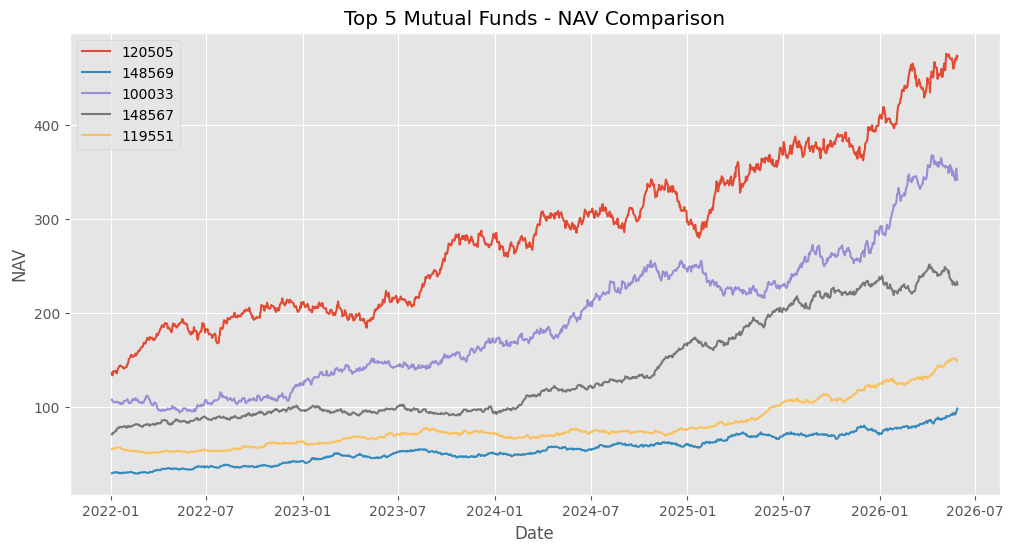

In [13]:
import matplotlib.pyplot as plt

# Top 5 funds by Fund Score
top5 = score.head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for amfi in top5:
    temp = nav[nav["amfi_code"] == amfi]
    plt.plot(temp["date"], temp["nav"], label=str(amfi))

plt.title("Top 5 Mutual Funds - NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison_chart.png")
plt.show()